# Train Phase:

    Normal Images
        ↓
    YOLO Feature Extractor
        ↓
    Online Adapter (initialized as identity)
        ↓
    Memory Bank of Normal Features

# Test-Time Phase:

    Incoming Image
        ↓
    YOLO Feature Extractor
        ↓
    Online Adapter
        ↓
    Compare with Memory Bank
        ↓
    Anomaly Score
        ↓
    Normal-like sample?
       ├─ No  → Output anomaly result
       └─ Yes → Online Adapter Update
                    ↓
                Update Memory Bank
                    ↓
                Output updated result

# Training Stage:
Normal samples are embedded by a frozen YOLO-based feature extractor and mapped through an adapter into a compact normal memory bank.

# Test-Time Stage:
Each incoming sample is encoded and compared against the normal memory bank to produce an anomaly score.

# Online Adaptation Stage:
When a test sample is assessed as sufficiently normal-like, it is used to update the adapter and enrich the memory bank, enabling continuous adaptation to distribution changes.

In [2]:
# ============================================================
# CELL 1 — Install packages
# Kaggle note:
# 1) Turn ON Internet in Notebook Settings
# 2) Turn ON GPU in Notebook Settings
# ============================================================
!pip -q install ultralytics scikit-learn

# ============================================================
# CELL 2 — Imports
# ============================================================
import os
import random
import shutil
from pathlib import Path
from collections import deque

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

from ultralytics import YOLO
import ultralytics

print("Ultralytics version:", ultralytics.__version__)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.3 MB/s eta 0:00:00:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.37
Device: cpu


In [3]:
# ============================================================
# CELL 3 — User config
# Change CATEGORY to another MVTec object later if needed
# ============================================================
MVTec_ROOT = Path("/kaggle/input/datasets/ipythonx/mvtec-ad")
CATEGORY = "bottle"   # e.g. bottle, cable, capsule, hazelnut, leather...
WORK_ROOT = Path("/kaggle/working/mvtec_yolo26_ttl")
IMG_SIZE = 224        # classification-friendly size
BATCH_SIZE = 32
NUM_WORKERS = 2 if DEVICE == "cuda" else 0

# Online TTL settings
MAX_MEMORY_BANK = 4000         # cap bank size to control memory
VAL_NORMAL_QUANTILE = 0.995    # threshold from validation normal scores
ONLINE_LR = 1e-4
ONLINE_STEPS = 1               # number of update steps per accepted sample
CONSISTENCY_WEIGHT = 1.0
ANCHOR_WEIGHT = 0.1
ACCEPT_MARGIN = 0.95           # online update only if score < threshold * margin

assert MVTec_ROOT.exists(), f"Path not found: {MVTec_ROOT}"
assert (MVTec_ROOT / CATEGORY).exists(), f"Category not found: {CATEGORY}"

print("Using category:", CATEGORY)
print("Input root:", MVTec_ROOT)
print("Work root:", WORK_ROOT)

Using category: bottle
Input root: /kaggle/input/datasets/ipythonx/mvtec-ad
Work root: /kaggle/working/mvtec_yolo26_ttl


In [4]:
# ============================================================
# CELL 4 — Convert MVTec category into a clean working layout
#
# Why do this?
# - MVTec images may be PNG and organized by defect folders
# - We convert everything to RGB JPG for a consistent pipeline
# - We create:
#     train/normal
#     val/normal
#     test/normal
#     test/anomaly
#
# Important:
# - This preserves the anomaly-detection protocol:
#   training uses only "good" images
# - Defect images stay in test/anomaly
# ============================================================
def reset_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def save_as_jpg(src_path: Path, dst_path: Path, size=(224, 224)):
    img = Image.open(src_path).convert("RGB")
    img = img.resize(size)
    img.save(dst_path, quality=95)

def prepare_mvtec_single_category(
    mvtec_root: Path,
    category: str,
    out_root: Path,
    img_size: int = 224,
    val_ratio: float = 0.2,
):
    category_root = mvtec_root / category
    train_good = sorted((category_root / "train" / "good").glob("*"))
    test_root = category_root / "test"

    # Output structure
    train_normal_dir = out_root / category / "train" / "normal"
    val_normal_dir   = out_root / category / "val" / "normal"
    test_normal_dir  = out_root / category / "test" / "normal"
    test_anom_dir    = out_root / category / "test" / "anomaly"

    for d in [train_normal_dir, val_normal_dir, test_normal_dir, test_anom_dir]:
        reset_dir(d)

    # Split normal train into train/val
    indices = list(range(len(train_good)))
    random.shuffle(indices)
    split_idx = int(len(indices) * (1 - val_ratio))
    train_idx = set(indices[:split_idx])

    # Convert train/val normal images
    for i, src in enumerate(train_good):
        stem = src.stem
        if i in train_idx:
            dst = train_normal_dir / f"{stem}.jpg"
        else:
            dst = val_normal_dir / f"{stem}.jpg"
        save_as_jpg(src, dst, size=(img_size, img_size))

    # Convert test images
    for defect_folder in sorted(test_root.iterdir()):
        if not defect_folder.is_dir():
            continue

        defect_name = defect_folder.name
        for src in sorted(defect_folder.glob("*")):
            stem = f"{defect_name}_{src.stem}.jpg"

            if defect_name == "good":
                dst = test_normal_dir / stem
            else:
                dst = test_anom_dir / stem

            save_as_jpg(src, dst, size=(img_size, img_size))

    return {
        "train_normal": train_normal_dir,
        "val_normal": val_normal_dir,
        "test_normal": test_normal_dir,
        "test_anomaly": test_anom_dir,
    }

paths = prepare_mvtec_single_category(
    mvtec_root=MVTec_ROOT,
    category=CATEGORY,
    out_root=WORK_ROOT,
    img_size=IMG_SIZE,
    val_ratio=0.2,
)

for k, v in paths.items():
    print(f"{k}: {v} -> {len(list(v.glob('*.jpg')))} images")

train_normal: /kaggle/working/mvtec_yolo26_ttl/bottle/train/normal -> 167 images
val_normal: /kaggle/working/mvtec_yolo26_ttl/bottle/val/normal -> 42 images
test_normal: /kaggle/working/mvtec_yolo26_ttl/bottle/test/normal -> 20 images
test_anomaly: /kaggle/working/mvtec_yolo26_ttl/bottle/test/anomaly -> 63 images


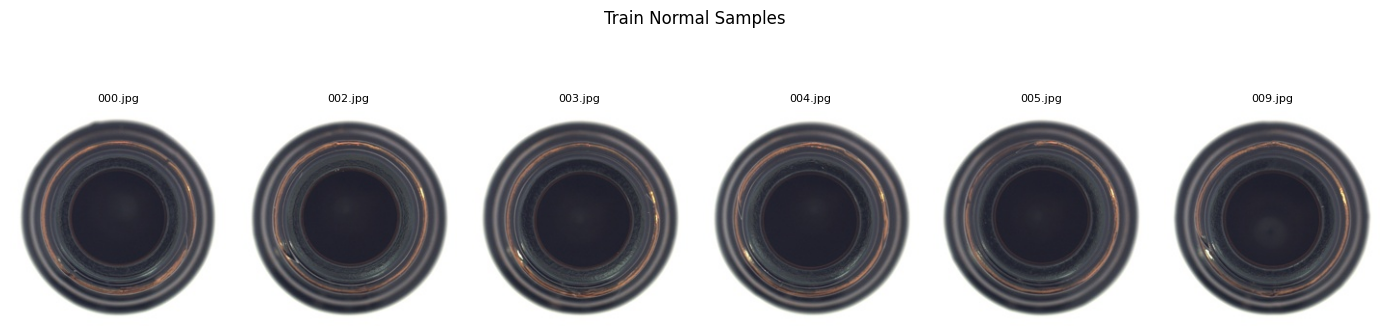

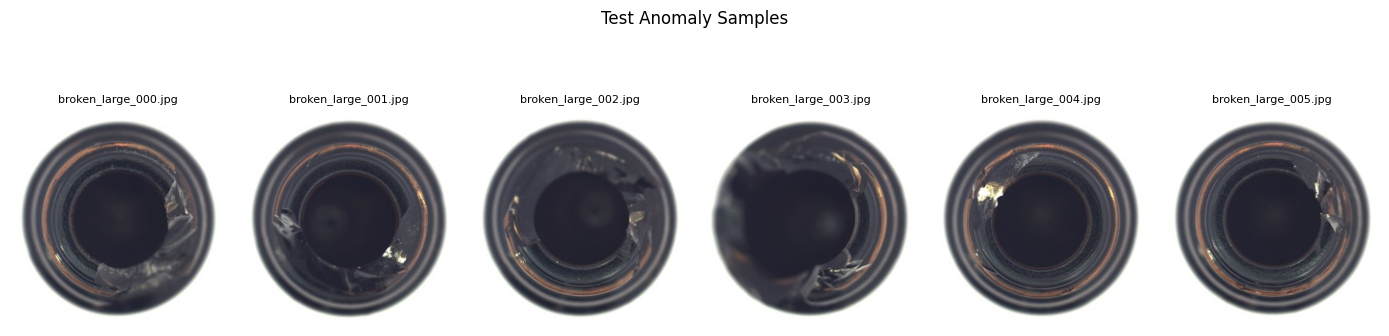

In [5]:
# ============================================================
# CELL 5 — Quick visual check
# ============================================================
def show_samples(folder: Path, n=6, title="Samples"):
    files = sorted(folder.glob("*.jpg"))[:n]
    plt.figure(figsize=(14, 4))
    for i, f in enumerate(files, 1):
        img = Image.open(f).convert("RGB")
        plt.subplot(1, n, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f.name[:20], fontsize=8)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(paths["train_normal"], n=6, title="Train Normal Samples")
show_samples(paths["test_anomaly"], n=6, title="Test Anomaly Samples")

In [6]:
# ============================================================
# CELL 6 — Dataset classes
# We keep labels simple:
#   0 = normal
#   1 = anomaly
# ============================================================
class MVTecBinaryDataset(Dataset):
    def __init__(self, image_paths, labels):
        self.image_paths = image_paths
        self.labels = labels

    def __len__(self):
        return len(self.image_paths)

    def _load_image(self, path):
        img = Image.open(path).convert("RGB")
        img = np.array(img).astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))  # HWC -> CHW
        return torch.tensor(img, dtype=torch.float32)

    def __getitem__(self, idx):
        x = self._load_image(self.image_paths[idx])
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y, str(self.image_paths[idx])

def get_loader_from_folder(folder: Path, label: int, batch_size=32, shuffle=False):
    image_paths = sorted(folder.glob("*.jpg"))
    labels = [label] * len(image_paths)
    ds = MVTecBinaryDataset(image_paths, labels)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
    )
    return ds, dl

train_ds, train_loader = get_loader_from_folder(paths["train_normal"], label=0, batch_size=BATCH_SIZE, shuffle=True)
val_ds, val_loader     = get_loader_from_folder(paths["val_normal"], label=0, batch_size=BATCH_SIZE, shuffle=False)

test_image_paths = sorted(paths["test_normal"].glob("*.jpg")) + sorted(paths["test_anomaly"].glob("*.jpg"))
test_labels = [0] * len(sorted(paths["test_normal"].glob("*.jpg"))) + [1] * len(sorted(paths["test_anomaly"].glob("*.jpg")))
test_ds = MVTecBinaryDataset(test_image_paths, test_labels)
test_loader = DataLoader(
    test_ds,
    batch_size=1,   # online adaptation is simpler sample-by-sample
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)

print("Train normal:", len(train_ds))
print("Val normal:", len(val_ds))
print("Test total:", len(test_ds), "| normal:", sum(np.array(test_labels) == 0), "| anomaly:", sum(np.array(test_labels) == 1))

Train normal: 167
Val normal: 42
Test total: 83 | normal: 20 | anomaly: 63


In [7]:
# ============================================================
# CELL 7 — YOLO26 feature extractor
#
# We use the latest Ultralytics classification backbone:
#   yolo26n-cls.pt
#
# Strategy:
# - Load YOLO26 classification model
# - Freeze the full backbone
# - Capture the input to the final Linear layer as the embedding
#
# This is a practical way to use YOLO as a feature extractor for anomaly scoring.
# ============================================================
class YOLO26FeatureExtractor(nn.Module):
    def __init__(self, model_name="yolo26n-cls.pt"):
        super().__init__()

        # Load Ultralytics classification model
        self.yolo = YOLO(model_name)
        self.core = self.yolo.model.to(DEVICE).eval()

        # Freeze all pretrained weights
        for p in self.core.parameters():
            p.requires_grad = False

        # Find the last Linear layer and hook its input as embedding
        self._cached_feat = None
        self.last_linear = None
        for m in self.core.modules():
            if isinstance(m, nn.Linear):
                self.last_linear = m

        if self.last_linear is None:
            raise RuntimeError("Could not find a final Linear layer for embedding extraction.")

        def pre_hook(module, inputs):
            # inputs is a tuple; the first item is the feature tensor entering the classifier
            self._cached_feat = inputs[0]

        self.hook = self.last_linear.register_forward_pre_hook(pre_hook)

    @torch.no_grad()
    def extract(self, x):
        """
        x: float tensor in [0, 1], shape [B, 3, H, W]
        returns: L2-normalized embedding [B, D]
        """
        self._cached_feat = None
        _ = self.core(x)  # forward pass populates the hook

        if self._cached_feat is None:
            raise RuntimeError("Feature hook did not capture embeddings.")

        feat = self._cached_feat
        if feat.ndim > 2:
            feat = torch.flatten(feat, start_dim=1)

        feat = F.normalize(feat, dim=1)
        return feat

feature_extractor = YOLO26FeatureExtractor(model_name="yolo26n-cls.pt")
print("YOLO26 feature extractor ready.")

YOLO26 feature extractor ready.


In [8]:
# ============================================================
# CELL 8 — Learnable online adapter
#
# This is the actual "test-time learning" part.
# We do not update the frozen YOLO backbone.
# We only update a lightweight adapter online.
#
# The adapter starts as identity.
# ============================================================
class OnlineAdapter(nn.Module):
    def __init__(self, feat_dim):
        super().__init__()
        self.proj = nn.Linear(feat_dim, feat_dim, bias=False)

        # Initialize as identity
        with torch.no_grad():
            self.proj.weight.copy_(torch.eye(feat_dim))

    def forward(self, x):
        x = self.proj(x)
        x = F.normalize(x, dim=1)
        return x

# Infer embedding dimension from one batch
x0, _, _ = next(iter(train_loader))
x0 = x0.to(DEVICE)
with torch.no_grad():
    f0 = feature_extractor.extract(x0)

FEAT_DIM = f0.shape[1]
adapter = OnlineAdapter(FEAT_DIM).to(DEVICE)
adapter_optimizer = torch.optim.Adam(adapter.parameters(), lr=ONLINE_LR)

print("Feature dim:", FEAT_DIM)

Feature dim: 1280


In [13]:
# ============================================================
# CELL 9 — Utility functions
# ============================================================
@torch.no_grad()
def build_memory_bank(loader, extractor, adapter_model):
    """
    Build memory bank from normal training images only.
    """
    bank = []
    extractor.core.eval()
    adapter_model.eval()

    for x, _, _ in loader:
        x = x.to(DEVICE)
        feat = extractor.extract(x)
        feat = adapter_model(feat)
        bank.append(feat.detach().cpu())

    bank = torch.cat(bank, dim=0)
    return bank

@torch.no_grad()
def anomaly_score(embedding, memory_bank):
    """
    embedding: [B, D]
    memory_bank: [N, D]
    returns: [B] anomaly scores
    Higher score = more anomalous
    """
    bank = memory_bank.to(embedding.device)
    sim = embedding @ bank.T
    max_sim, _ = sim.max(dim=1)
    score = 1.0 - max_sim
    return score
    
@torch.no_grad()
def anomaly_score_single(embedding, memory_bank):
    return anomaly_score(embedding, memory_bank)[0].item()
    
@torch.no_grad()
def nearest_normal_anchor(embedding, memory_bank):
    bank = memory_bank.to(embedding.device)
    sim = embedding @ bank.T
    idx = sim.argmax(dim=1)
    anchor = bank[idx]
    return anchor

def weak_aug(x):
    """
    Mild augmentation for consistency learning.
    x: [B, 3, H, W]
    """
    noise = torch.randn_like(x) * 0.01
    out = torch.clamp(x + noise, 0.0, 1.0)
    return out

def strong_aug(x):
    """
    Stronger augmentation for test-time consistency.
    """
    noise = torch.randn_like(x) * 0.03
    out = torch.clamp(x + noise, 0.0, 1.0)

    # Random horizontal flip
    if random.random() < 0.5:
        out = torch.flip(out, dims=[3])

    return out

def online_ttl_update(x, extractor, adapter_model, optimizer, memory_bank):
    """
    One online test-time learning update.
    We only call this when the sample is normal-like (score below threshold).
    """
    adapter_model.train()

    for _ in range(ONLINE_STEPS):
        xw = weak_aug(x)
        xs = strong_aug(x)

        with torch.no_grad():
            fw = extractor.extract(xw)
            fs = extractor.extract(xs)

        zw = adapter_model(fw)
        zs = adapter_model(fs)

        # Anchor to nearest memory feature
        with torch.no_grad():
            anchor = nearest_normal_anchor(zw.detach(), memory_bank).to(DEVICE)

        consistency_loss = F.mse_loss(zs, zw.detach())
        anchor_loss = F.mse_loss(zw, anchor)

        loss = CONSISTENCY_WEIGHT * consistency_loss + ANCHOR_WEIGHT * anchor_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    adapter_model.eval()

@torch.no_grad()
def compute_scores(loader, extractor, adapter_model, memory_bank):
    scores, labels, paths = [], [], []
    adapter_model.eval()

    for x, y, p in loader:
        x = x.to(DEVICE)
        feat = extractor.extract(x)
        emb = adapter_model(feat)

        batch_scores = anomaly_score(emb, memory_bank)   # shape [B]

        scores.extend(batch_scores.cpu().tolist())
        labels.extend(y.cpu().tolist())
        paths.extend(list(p))

    return scores, labels, paths

In [14]:
# ============================================================
# CELL 10 — Build initial memory bank
# ============================================================
adapter.eval()
memory_bank = build_memory_bank(train_loader, feature_extractor, adapter)
print("Initial memory bank shape:", tuple(memory_bank.shape))

Initial memory bank shape: (167, 1280)


In [15]:
# ============================================================
# CELL 11 — Calibrate threshold using validation normals only
#
# We estimate the anomaly threshold from the upper tail of scores on
# held-out normal images. This avoids using defect labels for threshold tuning.
# ============================================================
val_scores, _, _ = compute_scores(val_loader, feature_extractor, adapter, memory_bank)
threshold = float(np.quantile(val_scores, VAL_NORMAL_QUANTILE))

print("Validation normal score stats")
print("min:", np.min(val_scores))
print("mean:", np.mean(val_scores))
print("max:", np.max(val_scores))
print(f"Chosen threshold (q={VAL_NORMAL_QUANTILE}):", threshold)

Validation normal score stats
min: 0.0013864636421203613
mean: 0.003925412893295288
max: 0.009296774864196777
Chosen threshold (q=0.995): 0.009156525731086732


In [16]:
# ============================================================
# CELL 12 — Online test-time learning + evaluation
#
# Logic:
# 1) Score sample against current memory bank
# 2) If score is comfortably below threshold, treat it as normal-like
# 3) Perform online TTL update on the lightweight adapter
# 4) Re-embed and optionally add accepted sample to memory bank
# ============================================================
adapter.eval()

test_scores_before = []
test_scores_after = []
test_preds_after = []
test_gt = []
test_paths = []

memory_bank_online = memory_bank.clone()

for x, y, p in test_loader:
    x = x.to(DEVICE)
    gt = int(y.item())

    # ----- score before adaptation -----
    with torch.no_grad():
        feat_before = feature_extractor.extract(x)
        emb_before = adapter(feat_before)
        score_before = anomaly_score_single(emb_before, memory_bank_online)

    # ----- selective online update -----
    # only adapt on normal-like samples to reduce contamination risk
    if score_before < threshold * ACCEPT_MARGIN:
        online_ttl_update(
            x=x,
            extractor=feature_extractor,
            adapter_model=adapter,
            optimizer=adapter_optimizer,
            memory_bank=memory_bank_online,
        )

        # Recompute embedding after update
        with torch.no_grad():
            feat_after_tmp = feature_extractor.extract(x)
            emb_after_tmp = adapter(feat_after_tmp)

        # Add accepted sample to memory bank
        memory_bank_online = torch.cat(
            [memory_bank_online, emb_after_tmp.detach().cpu()],
            dim=0
        )

        # Cap memory bank size
        if memory_bank_online.shape[0] > MAX_MEMORY_BANK:
            memory_bank_online = memory_bank_online[-MAX_MEMORY_BANK:]

    # ----- final score after possible adaptation -----
    with torch.no_grad():
        feat_after = feature_extractor.extract(x)
        emb_after = adapter(feat_after)
        score_after = anomaly_score_single(emb_after, memory_bank_online)

    pred_after = 1 if score_after >= threshold else 0

    test_scores_before.append(score_before)
    test_scores_after.append(score_after)
    test_preds_after.append(pred_after)
    test_gt.append(gt)
    test_paths.append(p[0])

print("Online evaluation finished.")

Online evaluation finished.


In [17]:
# ============================================================
# CELL 13 — Metrics
# ============================================================
auroc_before = roc_auc_score(test_gt, test_scores_before)
auroc_after  = roc_auc_score(test_gt, test_scores_after)

print(f"Image-level AUROC before TTL : {auroc_before:.4f}")
print(f"Image-level AUROC after TTL  : {auroc_after:.4f}")

print("\nConfusion matrix (after TTL):")
print(confusion_matrix(test_gt, test_preds_after))

print("\nClassification report (after TTL):")
print(classification_report(test_gt, test_preds_after, target_names=["normal", "anomaly"], digits=4))

Image-level AUROC before TTL : 0.9532
Image-level AUROC after TTL  : 0.9369

Confusion matrix (after TTL):
[[17  3]
 [ 4 59]]

Classification report (after TTL):
              precision    recall  f1-score   support

      normal     0.8095    0.8500    0.8293        20
     anomaly     0.9516    0.9365    0.9440        63

    accuracy                         0.9157        83
   macro avg     0.8806    0.8933    0.8866        83
weighted avg     0.9174    0.9157    0.9164        83



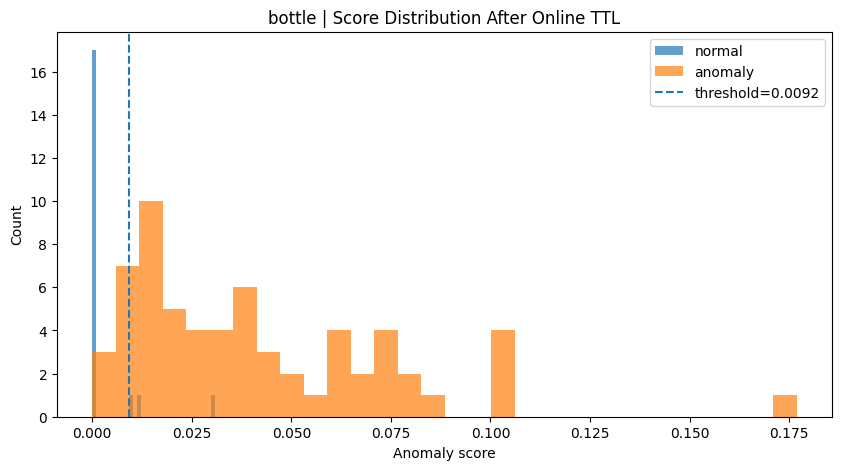

In [18]:
# ============================================================
# CELL 14 — Plot score distributions
# ============================================================
normal_scores = [s for s, y in zip(test_scores_after, test_gt) if y == 0]
anomaly_scores = [s for s, y in zip(test_scores_after, test_gt) if y == 1]

plt.figure(figsize=(10, 5))
plt.hist(normal_scores, bins=30, alpha=0.7, label="normal")
plt.hist(anomaly_scores, bins=30, alpha=0.7, label="anomaly")
plt.axvline(threshold, linestyle="--", label=f"threshold={threshold:.4f}")
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.title(f"{CATEGORY} | Score Distribution After Online TTL")
plt.legend()
plt.show()

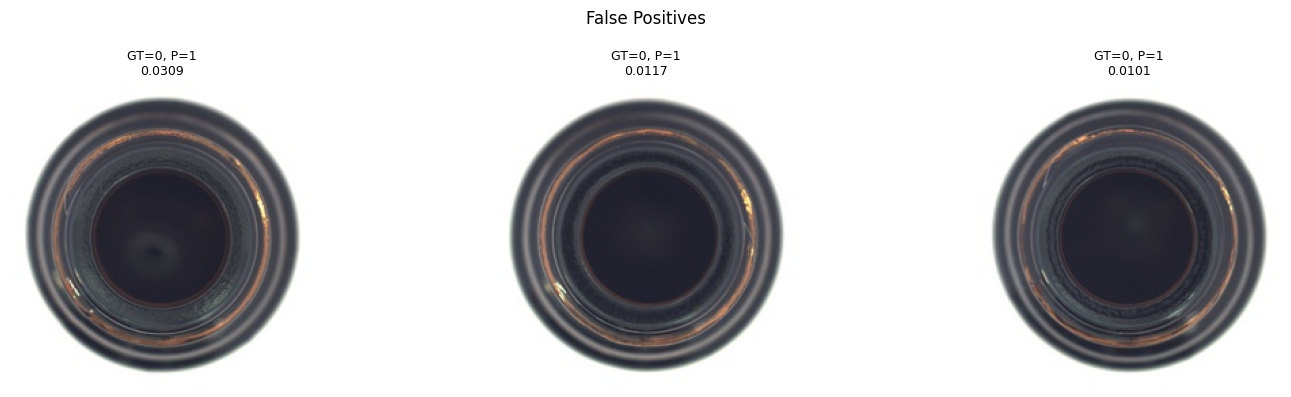

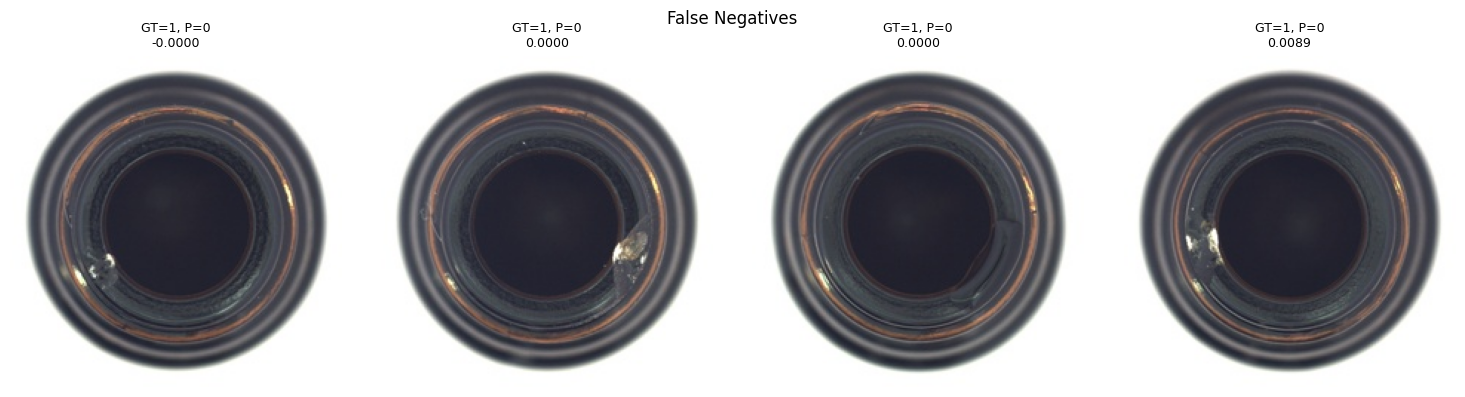

In [19]:
# ============================================================
# CELL 15 — Show hardest mistakes
# ============================================================
results = list(zip(test_paths, test_gt, test_scores_after, test_preds_after))

# False positives: normal predicted as anomaly
fps = [r for r in results if r[1] == 0 and r[3] == 1]
fps = sorted(fps, key=lambda x: x[2], reverse=True)[:6]

# False negatives: anomaly predicted as normal
fns = [r for r in results if r[1] == 1 and r[3] == 0]
fns = sorted(fns, key=lambda x: x[2])[:6]

def show_error_cases(cases, title):
    if len(cases) == 0:
        print(f"No cases for: {title}")
        return
    plt.figure(figsize=(15, 4))
    for i, (path, gt, score, pred) in enumerate(cases, 1):
        img = Image.open(path).convert("RGB")
        plt.subplot(1, len(cases), i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"GT={gt}, P={pred}\n{score:.4f}", fontsize=9)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_error_cases(fps, "False Positives")
show_error_cases(fns, "False Negatives")

In [20]:
# ============================================================
# CELL 16 — Save outputs
# ============================================================
OUT_DIR = WORK_ROOT / CATEGORY / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(OUT_DIR / "test_scores_before.npy", np.array(test_scores_before))
np.save(OUT_DIR / "test_scores_after.npy", np.array(test_scores_after))
np.save(OUT_DIR / "test_gt.npy", np.array(test_gt))

torch.save({
    "adapter_state_dict": adapter.state_dict(),
    "threshold": threshold,
    "category": CATEGORY,
    "img_size": IMG_SIZE,
}, OUT_DIR / "ttl_adapter.pt")

print("Saved to:", OUT_DIR)

Saved to: /kaggle/working/mvtec_yolo26_ttl/bottle/outputs
